# Data Preparation

## Load Library

In [1]:
# load library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import cv2
import os
from pathlib import Path
import pickle
from sklearn.utils import resample

# set style untuk visualisasi
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

In [2]:
RANDOM_STATE = 42

## Load Dataset Images and List of Attribute

In [3]:
# load dataset celeba

# path dataset di Kaggle
BASE_PATH = '/kaggle/input/celeba-dataset'
IMAGE_PATH = f'{BASE_PATH}/img_align_celeba/img_align_celeba'
ATTR_PATH = f'{BASE_PATH}/list_attr_celeba.csv'

# load attributes CSV
df_attr = pd.read_csv(ATTR_PATH)

# display info 
print(f"Total images: {len(df_attr)}")
print(f"Total attributes: {df_attr.shape[1] - 1}")  # -1 karena kolom pertama adalah image_id
print("\nFirst 5 rows:")
print(df_attr.head())

# cek attribute columns
print("\nAvailable attributes:")
print(df_attr.columns.tolist())

Total images: 202599
Total attributes: 40

First 5 rows:
     image_id  5_o_Clock_Shadow  Arched_Eyebrows  Attractive  Bags_Under_Eyes  \
0  000001.jpg                -1                1           1               -1   
1  000002.jpg                -1               -1          -1                1   
2  000003.jpg                -1               -1          -1               -1   
3  000004.jpg                -1               -1           1               -1   
4  000005.jpg                -1                1           1               -1   

   Bald  Bangs  Big_Lips  Big_Nose  Black_Hair  ...  Sideburns  Smiling  \
0    -1     -1        -1        -1          -1  ...         -1        1   
1    -1     -1        -1         1          -1  ...         -1        1   
2    -1     -1         1        -1          -1  ...         -1       -1   
3    -1     -1        -1        -1          -1  ...         -1       -1   
4    -1     -1         1        -1          -1  ...         -1       -1   

   St

## Display List of Images

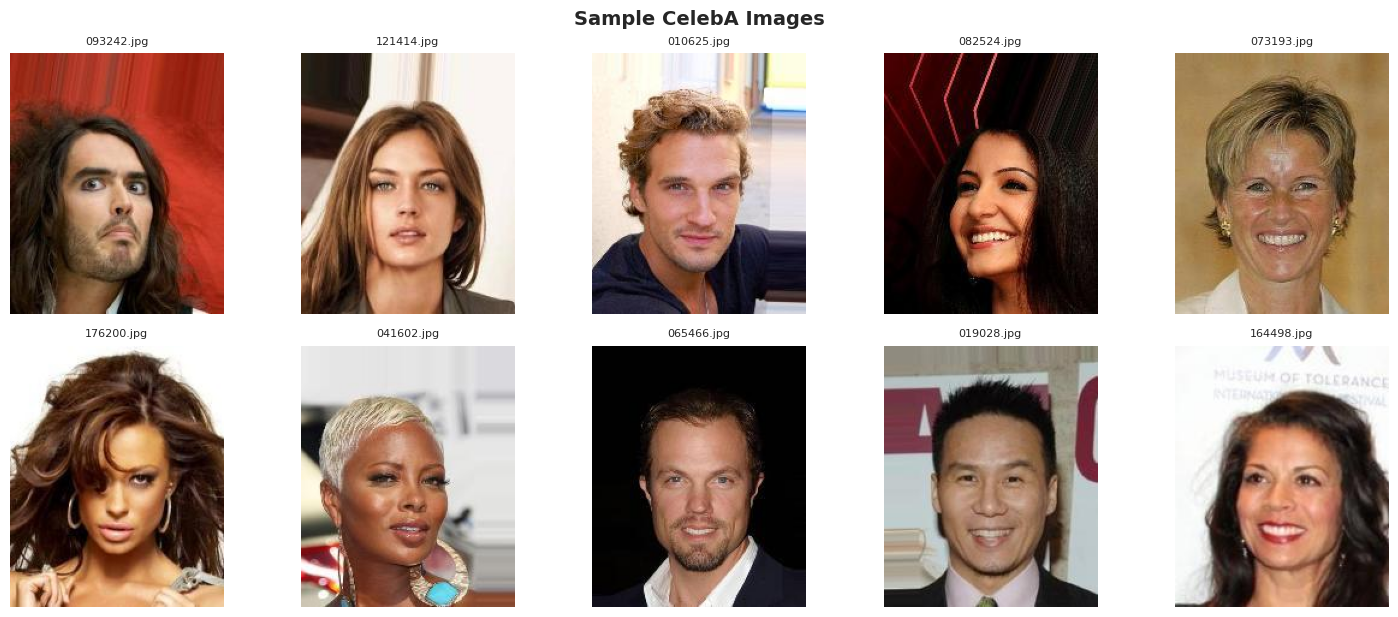


Image dimensions: (178, 218)
Image mode: RGB


In [4]:
# ambil sample random images
sample_images = df_attr.sample(n=10, random_state=RANDOM_STATE)['image_id'].values

# display images
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.ravel()

for idx, img_name in enumerate(sample_images):
    img_path = os.path.join(IMAGE_PATH, img_name)
    img = Image.open(img_path)
    
    axes[idx].imshow(img)
    axes[idx].set_title(img_name, fontsize=8)
    axes[idx].axis('off')

plt.tight_layout()
plt.suptitle('Sample CelebA Images', y=1.02, fontsize=14, fontweight='bold')
plt.show()

# cek dimensi images
sample_img = Image.open(os.path.join(IMAGE_PATH, df_attr.iloc[0]['image_id']))
print(f"\nImage dimensions: {sample_img.size}")  # Width x Height
print(f"Image mode: {sample_img.mode}")  # RGB

## Prepare List of Attribute that Match the Attributes in the Images

In [5]:
# filter attributes yang relevan untuk project
relevant_attrs = ['Male', 'Young', 'Smiling', 'Mouth_Slightly_Open']

# buat dataframe baru dengan attributes yang relevan
df_prepared = df_attr[['image_id'] + relevant_attrs].copy()

# convert -1/1 menjadi 0/1 untuk kemudahan
for col in relevant_attrs:
    df_prepared[col] = df_prepared[col].apply(lambda x: 1 if x == 1 else 0)

# buat label Gender yang lebih readable
df_prepared['Gender'] = df_prepared['Male'].apply(lambda x: 'Male' if x == 1 else 'Female')

print(df_prepared.head(10))
print(f"\nPrepared dataset shape: {df_prepared.shape}")

     image_id  Male  Young  Smiling  Mouth_Slightly_Open  Gender
0  000001.jpg     0      1        1                    1  Female
1  000002.jpg     0      1        1                    1  Female
2  000003.jpg     1      1        0                    0    Male
3  000004.jpg     0      1        0                    0  Female
4  000005.jpg     0      1        0                    0  Female
5  000006.jpg     0      1        0                    1  Female
6  000007.jpg     1      1        0                    0    Male
7  000008.jpg     1      1        0                    0    Male
8  000009.jpg     0      1        1                    1  Female
9  000010.jpg     0      1        0                    0  Female

Prepared dataset shape: (202599, 6)


## Display Images with Gender Name

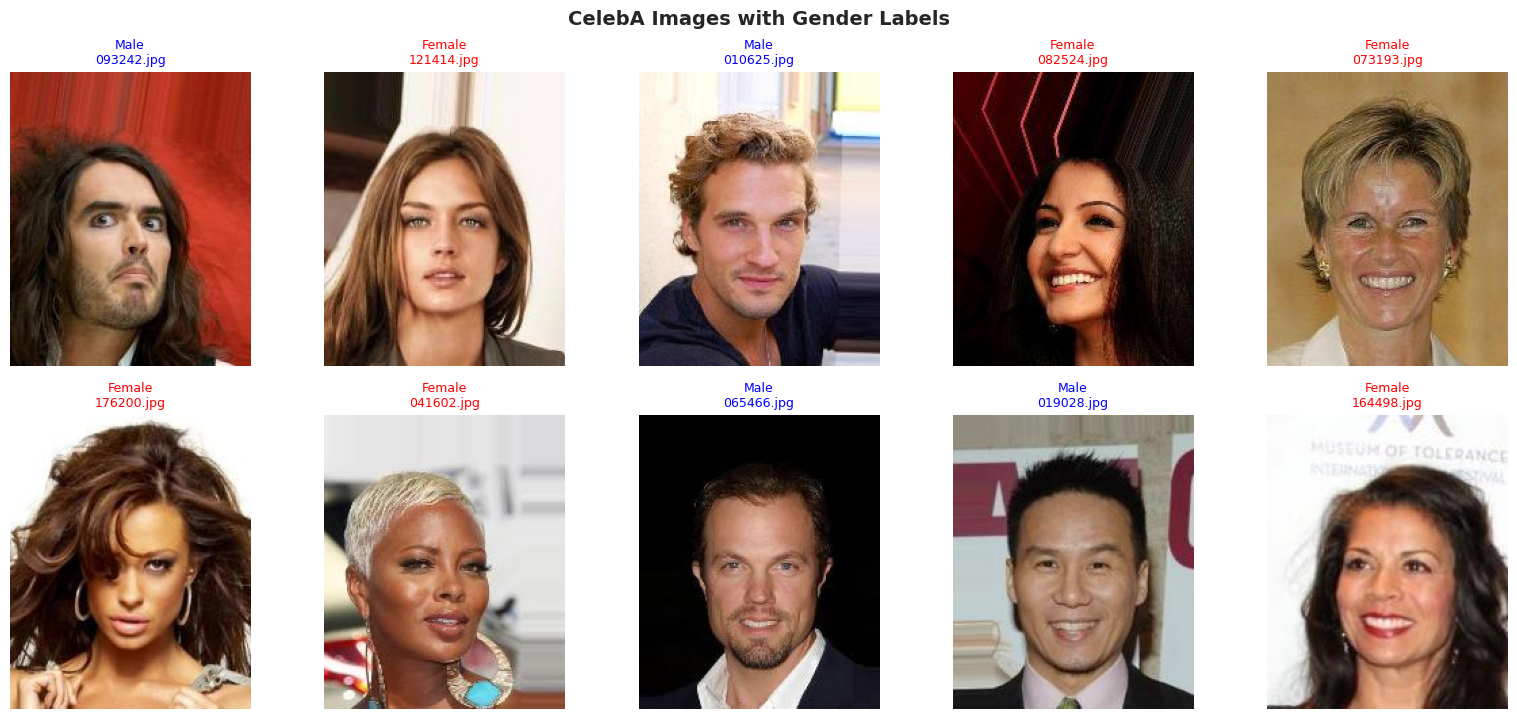

In [6]:
# sample 10 images dengan gender label
sample_df = df_prepared.sample(n=10, random_state=RANDOM_STATE)

fig, axes = plt.subplots(2, 5, figsize=(16, 7))
axes = axes.ravel()

for idx, (_, row) in enumerate(sample_df.iterrows()):
    img_path = os.path.join(IMAGE_PATH, row['image_id'])
    img = Image.open(img_path)
    
    # display
    axes[idx].imshow(img)
    axes[idx].set_title(f"{row['Gender']}\n{row['image_id']}", 
                        fontsize=9, 
                        color='blue' if row['Gender'] == 'Male' else 'red')
    axes[idx].axis('off')

plt.tight_layout()
plt.suptitle('CelebA Images with Gender Labels', y=1.02, fontsize=14, fontweight='bold')
plt.show()

## Count Total Images Man and Female

GENDER DISTRIBUTION
Gender
Female    118165
Male       84434
Name: count, dtype: int64

Total: 202599

Percentage:
Gender
Female    58.324572
Male      41.675428
Name: count, dtype: float64


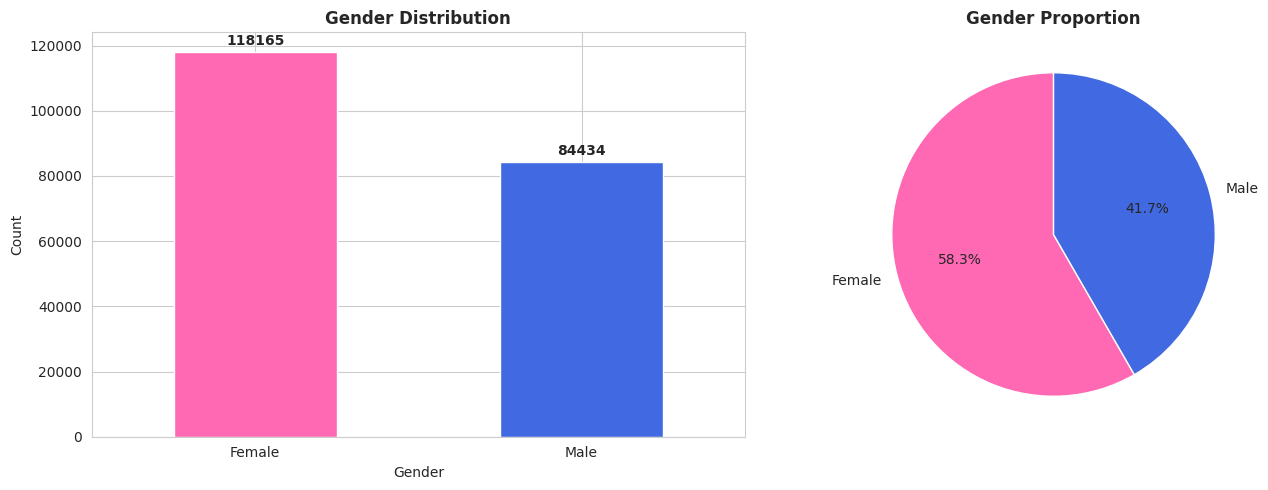

In [7]:
# count distribution
gender_counts = df_prepared['Gender'].value_counts()

print("=" * 50)
print("GENDER DISTRIBUTION")
print("=" * 50)
print(gender_counts)
print(f"\nTotal: {gender_counts.sum()}")
print(f"\nPercentage:")
print(gender_counts / gender_counts.sum() * 100)

# visualisasi
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# bar plot
gender_counts.plot(kind='bar', ax=axes[0], color=['#FF69B4', '#4169E1'])
axes[0].set_title('Gender Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Gender')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

# add value labels on bars
for i, v in enumerate(gender_counts):
    axes[0].text(i, v + 1000, str(v), ha='center', va='bottom', fontweight='bold')

# pie chart
colors = ['#FF69B4', '#4169E1']
axes[1].pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', 
            colors=colors, startangle=90)
axes[1].set_title('Gender Proportion', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

## Balancing Total Images Man and Female

In [8]:
# pisahkan berdasarkan gender
df_female = df_prepared[df_prepared['Gender'] == 'Female']
df_male = df_prepared[df_prepared['Gender'] == 'Male']

print(f"Female: {len(df_female)}, Male: {len(df_male)}")

# undersample female ke jumlah male
df_female_downsampled = resample(df_female, 
                                  replace=False,  # tanpa replacement
                                  n_samples=len(df_male),  # match male count
                                  random_state=RANDOM_STATE)

# gabungkan kembali
df_balanced = pd.concat([df_female_downsampled, df_male])
df_balanced = df_balanced.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)  # Shuffle

print(f"\nBalanced dataset shape: {df_balanced.shape}")
print("\nNew gender distribution:")
print(df_balanced['Gender'].value_counts())

Female: 118165, Male: 84434

Balanced dataset shape: (168868, 6)

New gender distribution:
Gender
Female    84434
Male      84434
Name: count, dtype: int64


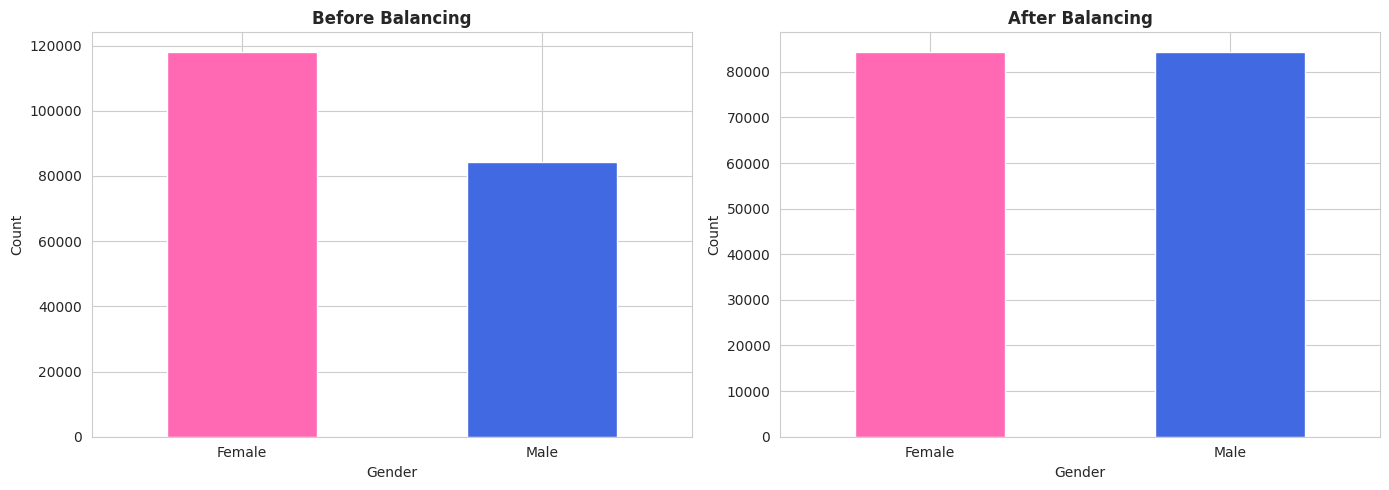

In [9]:
# visualisasi hasil balancing
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# before balancing
gender_counts.plot(kind='bar', ax=axes[0], color=['#FF69B4', '#4169E1'])
axes[0].set_title('Before Balancing', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

# after balancing
df_balanced['Gender'].value_counts().plot(kind='bar', ax=axes[1], color=['#FF69B4', '#4169E1'])
axes[1].set_title('After Balancing', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

## Save Prepared Data

In [10]:
# save balanced dataframe
output_path = '/kaggle/working/'
df_balanced.to_csv(f'{output_path}celeba_prepared_balanced.csv', index=False)
print(f"✓ Saved balanced dataframe: {len(df_balanced)} rows")

# save metadata untuk reference
metadata = {
    'total_images': len(df_balanced),
    'gender_distribution': df_balanced['Gender'].value_counts().to_dict(),
    'attributes': relevant_attrs,
    'image_size': sample_img.size,
    'balancing_method': 'undersampling'
}

with open(f'{output_path}preparation_metadata.pkl', 'wb') as f:
    pickle.dump(metadata, f)
print("✓ Saved metadata")

# optional: Save list of image paths untuk efficiency
image_list = df_balanced['image_id'].tolist()
with open(f'{output_path}image_list.pkl', 'wb') as f:
    pickle.dump(image_list, f)
print("✓ Saved image list")

print("\n" + "="*50)
print("DATA PREPARATION COMPLETED!")
print("="*50)
print(f"Output files di: /kaggle/working/")
print("- celeba_prepared_balanced.csv")
print("- preparation_metadata.pkl")
print("- image_list.pkl")

✓ Saved balanced dataframe: 168868 rows
✓ Saved metadata
✓ Saved image list

DATA PREPARATION COMPLETED!
Output files di: /kaggle/working/
- celeba_prepared_balanced.csv
- preparation_metadata.pkl
- image_list.pkl
